In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
import shap

# For DeLong test
from roc_delong import delong_roc_test

# Paths
nhanes_path = "../data/03_processed/nhanes_final.csv"
brfss_path = "../data/03_processed/brfss_final.csv"
pima_path   = "../data/03_processed/pima_final.csv"

# Load data
nhanes = pd.read_csv(nhanes_path)
brfss  = pd.read_csv(brfss_path)
pima   = pd.read_csv(pima_path)

print("NHANES shape:", nhanes.shape)
print("BRFSS shape:", brfss.shape)
print("PIMA shape:", pima.shape)


c:\diabetes_prediction_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


NHANES shape: (15685, 14)
BRFSS shape: (1285783, 10)
PIMA shape: (768, 9)


In [2]:
import pandas as pd

nhanes = pd.read_csv("../data/03_processed/nhanes_final.csv")
brfss  = pd.read_csv("../data/03_processed/brfss_final.csv")

print("NHANES columns:", nhanes.columns.tolist())
print("BRFSS columns:", brfss.columns.tolist())

print("\nNHANES head:")
display(nhanes.head())

print("\nBRFSS head:")
display(brfss.head())


NHANES columns: ['Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke', 'Family_History_Diabetes', 'Total_Cholesterol', 'HDL_Cholesterol', 'Diabetes_Outcome']
BRFSS columns: ['Diabetes_Outcome', 'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'General_Health', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke']

NHANES head:


,Age,Gender,Race_Ethnicity,BMI,Systolic_BP,Diastolic_BP,Smoking_Status,Physical_Activity,History_Heart_Attack,History_Stroke,Family_History_Diabetes,Total_Cholesterol,HDL_Cholesterol,Diabetes_Outcome
0,62.0,1.0,3.0,27.8,128.0,70.0,1.0,2.0,2.0,2.0,1.0,173.0,46.0,1
1,53.0,1.0,3.0,30.8,146.0,88.0,1.0,2.0,2.0,2.0,2.0,265.0,63.0,0
2,78.0,1.0,3.0,28.8,138.0,46.0,1.0,2.0,2.0,2.0,2.0,229.0,30.0,1
3,56.0,2.0,3.0,42.4,132.0,72.0,2.0,2.0,2.0,2.0,2.0,174.0,61.0,0
4,42.0,2.0,4.0,20.3,100.0,70.0,2.0,2.0,2.0,2.0,2.0,204.0,53.0,0



BRFSS head:


,Diabetes_Outcome,Age,Gender,Race_Ethnicity,BMI,General_Health,Smoking_Status,Physical_Activity,History_Heart_Attack,History_Stroke
0,1.0,57.5,1.0,1.0,16.60,2.0,1.0,1.0,0.0,0.0
1,0.0,67.5,1.0,2.0,29.18,3.0,NaN,1.0,0.0,0.0
2,0.0,67.5,1.0,2.0,NaN,3.0,0.0,1.0,0.0,0.0
3,0.0,80.0,1.0,1.0,NaN,1.0,0.0,0.0,0.0,0.0
4,0.0,80.0,1.0,1.0,20.34,2.0,0.0,1.0,0.0,1.0


In [ ]:
table_df.to_csv("../results/table1_characteristics.csv", index=False)

In [4]:
# final_analysis.py
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2, norm
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import xgboost as xgb
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, brier_score_loss
from sklearn.utils import resample
import shap

# --- MODIFIED IMPORT ---
# Ensure this path is correct relative to where you run the script
from roc_delong import delong_roc_test

# -------------------------
# Paths & output directory
# -------------------------
NHANES_PATH = "./data/03_processed/nhanes_final.csv"
BRFSS_PATH  = "./data/03_processed/brfss_final.csv"
PIMA_PATH   = "./data/03_processed/pima_final.csv"
OUT_DIR = "./results"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------------
# Load
# -------------------------
nhanes = pd.read_csv(NHANES_PATH)
brfss  = pd.read_csv(BRFSS_PATH)
pima   = pd.read_csv(PIMA_PATH)

print("Loaded:")
print(f" NHANES: {nhanes.shape}")
print(f" BRFSS : {brfss.shape}")
print(f" PIMA  : {pima.shape}")

# -------------------------
# CLEAN / MAPPING (consistent with your script)
# -------------------------
nhanes["Gender_Clean"] = nhanes["Gender"].map({1: "Male", 2: "Female"})
brfss["Gender_Clean"]  = brfss["Gender"].map({0: "Male", 1: "Female"})

race_map = {1: "White, Non-Hispanic", 2: "Black, Non-Hispanic", 3: "Hispanic", 4: "Other/Multiracial"}
nhanes["Race_Clean"] = nhanes["Race_Ethnicity"].map(race_map)
brfss["Race_Clean"]  = brfss["Race_Ethnicity"].map(race_map)

# Diabetes clean columns (0/1)
nhanes = nhanes.dropna(subset=["Diabetes_Outcome"]).copy()
nhanes["Diabetes_Clean"] = nhanes["Diabetes_Outcome"].astype(int)
brfss = brfss.dropna(subset=["Diabetes_Outcome"]).copy()
brfss["Diabetes_Clean"] = brfss["Diabetes_Outcome"].astype(int)

# -------------------------
# Helper utilities
# -------------------------
# Your existing helper functions are great and retained here
def summarize_continuous(var, d1, d2):
    d1_non = d1[var].dropna().astype(float)
    d2_non = d2[var].dropna().astype(float)
    mean1, std1 = d1_non.mean(), d1_non.std()
    mean2, std2 = d2_non.mean(), d2_non.std()
    _, p = stats.ttest_ind(d1_non, d2_non, equal_var=False)
    return (f"{mean1:.1f} ({std1:.1f})", f"{mean2:.1f} ({std2:.1f})", p)

def summarize_categorical(var, d1, d2):
    s1 = d1[var].fillna("Missing").astype(str).value_counts()
    s2 = d2[var].fillna("Missing").astype(str).value_counts()
    # Create contingency table for chi-square
    contingency = pd.crosstab(
        pd.concat([d1.assign(cohort='d1'), d2.assign(cohort='d2')])['cohort'],
        pd.concat([d1, d2])[var].fillna("Missing")
    )
    try:
        _, p, _, _ = stats.chi2_contingency(contingency)
    except Exception:
        p = np.nan
    
    rows = []
    all_cats = sorted(set(s1.index).union(set(s2.index)))
    for c in all_cats:
        n1 = s1.get(c, 0)
        n2 = s2.get(c, 0)
        rows.append((c, f"{n1} ({n1/len(d1)*100:.1f})", f"{n2} ({n2/len(d2)*100:.1f})"))
    return rows, p

# -------------------------
# TABLE 1: Cohort characteristics
# This section remains as you wrote it, it correctly generates the required stats.
# The p-values will now be correctly captured and saved.
# -------------------------
print("\n--- Generating Table 1: Cohort Characteristics ---")
table1 = []
# Total Participants
table1.append(["Total Participants (N)", len(nhanes), len(brfss), ""])

# Continuous
age_stats = summarize_continuous("Age", nhanes, brfss)
bmi_stats = summarize_continuous("BMI", nhanes, brfss)
table1.append(["Age, Mean (SD)", age_stats[0], age_stats[1], f"{age_stats[2]:.3g}"])
table1.append(["BMI, Mean (SD)", bmi_stats[0], bmi_stats[1], f"{bmi_stats[2]:.3g}"])

# Categorical
def add_categorical_to_table(var_name, clean_col, df1, df2, tbl):
    rows, p_val = summarize_categorical(clean_col, df1, df2)
    tbl.append([var_name, "", "", f"{p_val:.3g}"])
    for row in sorted(rows, key=lambda x: x[0]): # Sort for consistency
        tbl.append([f"  {row[0]}", row[1], row[2], ""])

add_categorical_to_table("Gender", "Gender_Clean", nhanes, brfss, table1)
add_categorical_to_table("Race/Ethnicity", "Race_Clean", nhanes, brfss, table1)

# Diabetes outcome (showing only 'Yes' as in your manuscript)
diab_rows, diab_p = summarize_categorical("Diabetes_Clean", nhanes, brfss)
table1.append(["Diabetes Outcome, Yes (%)", "", "", f"{diab_p:.3g}"])
for row in diab_rows:
    if str(row[0]) == '1': # Assuming 1 is Yes
         table1.append([f"  Yes", row[1], row[2], ""])

table1_df = pd.DataFrame(table1, columns=["Characteristic", f"NHANES Development Cohort (N={len(nhanes)})", f"BRFSS External Validation Cohort (N={len(brfss)})", "p-value"])
table1_df.to_csv(os.path.join(OUT_DIR, "TABLE_1_cohort_characteristics.csv"), index=False)
print("Saved Table 1 ->", os.path.join(OUT_DIR, "TABLE_1_cohort_characteristics.csv"))
print(table1_df)


# -------------------------
# Prepare features for modeling
# -------------------------
features_to_use = ["Age", "Gender", "Race_Ethnicity", "BMI"]
target = "Diabetes_Outcome"

X_nhanes = nhanes[features_to_use]
y_nhanes = nhanes[target]
X_brfss = brfss[features_to_use]
y_brfss = brfss[target]

# Preprocessing pipeline
numeric_features = ["Age", "BMI"]
categorical_features = ["Gender", "Race_Ethnicity"]

# Impute and Scale numeric
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Fit on NHANES only to prevent data leakage from BRFSS
preprocessor.fit(X_nhanes)
X_nhanes_processed = preprocessor.transform(X_nhanes)
X_brfss_processed = preprocessor.transform(X_brfss)

# -------------------------
# TABLE 2: Internal validation (nested CV)
# This section now saves all required metrics including CI, Sens, Spec, PPV, NPV.
# -------------------------
print("\n--- Generating Table 2: Internal Validation Performance ---")
models = {
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(solver="liblinear", max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42)
}
param_grids = {
    "XGBoost": {"n_estimators": [100, 200], "max_depth": [3, 5], "learning_rate": [0.05, 0.1]},
    "Random Forest": {"n_estimators": [100, 200], "max_depth": [10, 20]},
    "Logistic Regression": {"C": [0.1, 1.0, 10.0], "penalty": ["l1", "l2"]},
    "SVM": {"C": [0.1, 1.0], "kernel": ["rbf"]}
}

outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

table2_rows = []
for name, model in models.items():
    print(f"Running nested CV for: {name}")
    # Create a full pipeline with preprocessing
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    
    # Adjust param_grid keys to work with pipeline
    pipeline_param_grid = {f'classifier__{k}': v for k, v in param_grids[name].items()}
    
    fold_aucs = []
    fold_metrics = []

    for train_idx, test_idx in outer_cv.split(X_nhanes, y_nhanes):
        X_tr, X_te = X_nhanes.iloc[train_idx], X_nhanes.iloc[test_idx]
        y_tr, y_te = y_nhanes.iloc[train_idx], y_nhanes.iloc[test_idx]

        grid = GridSearchCV(pipeline, pipeline_param_grid, cv=inner_cv, scoring="roc_auc", n_jobs=-1)
        grid.fit(X_tr, y_tr)
        best = grid.best_estimator_
        
        y_prob = best.predict_proba(X_te)[:, 1]
        fold_aucs.append(roc_auc_score(y_te, y_prob))
        
        # Use a standard 0.5 threshold for these metrics as Youden's can vary wildly
        y_pred = (y_prob >= 0.5).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
        npv = tn / (tn + fn) if (tn + fn) > 0 else 0
        fold_metrics.append((sens, spec, ppv, npv))

    mean_auc = np.mean(fold_aucs)
    std_auc = np.std(fold_aucs)
    ci_lower, ci_upper = np.percentile(fold_aucs, [2.5, 97.5]) # CI from folds
    
    metrics_avg = np.mean(fold_metrics, axis=0)
    table2_rows.append([name, mean_auc, std_auc, f"[{ci_lower:.4f}, {ci_upper:.4f}]", *metrics_avg])

table2_df = pd.DataFrame(table2_rows, columns=["Model", "Mean AUC", "Std Dev", "95% CI", "Sensitivity", "Specificity", "PPV", "NPV"])
table2_df.to_csv(os.path.join(OUT_DIR, "TABLE_2_internal_validation.csv"), index=False)
print("Saved Table 2 ->", os.path.join(OUT_DIR, "TABLE_2_internal_validation.csv"))
print(table2_df)


# -------------------------
# Train final XGBoost and get predictions for subsequent tables
# -------------------------
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42, n_estimators=200, max_depth=5, learning_rate=0.05))
])
final_pipeline.fit(X_nhanes, y_nhanes)
y_brfss_prob = final_pipeline.predict_proba(X_brfss)[:, 1]

# -------------------------
# TABLE 3: Baseline Model Comparisons (Ablation Study)
# --- ADDED CODE: Sequential DeLong tests for p-values ---
# -------------------------
print("\n--- Generating Table 3: Baseline Model Comparisons ---")
table3_rows = []
model_predictions = {}

def bootstrap_auc_ci(y_true, y_prob, n_boot=1000):
    aucs = [roc_auc_score(y_true_boot, y_prob_boot) 
            for y_true_boot, y_prob_boot in (resample(y_true, y_prob) for _ in range(n_boot))
            if len(np.unique(y_true_boot)) > 1]
    return np.percentile(aucs, [2.5, 97.5])

# Age only
lr_age = Pipeline(steps=[('ct', ColumnTransformer([('num', SimpleImputer(strategy='median'), ['Age'])])), ('lr', LogisticRegression())])
lr_age.fit(X_brfss[['Age']], y_brfss)
prob_age = lr_age.predict_proba(X_brfss[['Age']])[:, 1]
model_predictions['Age only'] = prob_age

# Age + BMI
lr_age_bmi = Pipeline(steps=[('ct', ColumnTransformer([('num', SimpleImputer(strategy='median'), ['Age', 'BMI'])])), ('lr', LogisticRegression())])
lr_age_bmi.fit(X_brfss[['Age', 'BMI']], y_brfss)
prob_age_bmi = lr_age_bmi.predict_proba(X_brfss[['Age', 'BMI']])[:, 1]
model_predictions['Age + BMI'] = prob_age_bmi

# Age + BMI + Gender
lr_abg = Pipeline(steps=[('ct', ColumnTransformer([('num', SimpleImputer(strategy='median'), ['Age', 'BMI']), ('cat', OneHotEncoder(), ['Gender'])])), ('lr', LogisticRegression())])
lr_abg.fit(X_brfss[['Age', 'BMI', 'Gender']], y_brfss)
prob_abg = lr_abg.predict_proba(X_brfss[['Age', 'BMI', 'Gender']])[:, 1]
model_predictions['Age + BMI + Gender'] = prob_abg

# Full XGBoost Model
model_predictions['Full XGBoost Model'] = y_brfss_prob

# Calculate AUCs, CIs, and sequential p-values
previous_prob = None
for name, prob in model_predictions.items():
    auc = roc_auc_score(y_brfss, prob)
    ci = bootstrap_auc_ci(y_brfss, prob)
    p_value = '-'
    if previous_prob is not None:
        # Use DeLong test for correlated ROC curves
        p_value = delong_roc_test(y_brfss.values, prob, previous_prob)[0]
    table3_rows.append([name, auc, f"[{ci[0]:.4f}, {ci[1]:.4f}]", p_value])
    previous_prob = prob

table3_df = pd.DataFrame(table3_rows, columns=["Model", "AUC", "95% CI", "p-value*"])
table3_df.to_csv(os.path.join(OUT_DIR, "TABLE_3_baseline_comparisons.csv"), index=False)
print("Saved Table 3 ->", os.path.join(OUT_DIR, "TABLE_3_baseline_comparisons.csv"))
print(table3_df)

# -------------------------
# TABLE 4: Fairness Analysis
# --- ADDED CODE: n, CI, and p-values for all subgroups ---
# -------------------------
print("\n--- Generating Table 4: Fairness Analysis ---")

def compare_independent_aucs(y1, p1, y2, p2):
    """Calculates p-value for difference between two independent AUCs."""
    n1, n2 = len(y1), len(y2)
    auc1, auc2 = roc_auc_score(y1, p1), roc_auc_score(y2, p2)
    # DeLong's variance formula for a single AUC
    def get_auc_variance(y, p):
        pos_mask = (y == 1)
        neg_mask = (y == 0)
        p_pos, p_neg = p[pos_mask], p[neg_mask]
        m, n = len(p_pos), len(p_neg)
        # Structural components
        v10 = np.array([np.mean(p_pos[i] > p_neg) for i in range(m)])
        v01 = np.array([np.mean(p_pos > p_neg[j]) for j in range(n)])
        var_auc = np.var(v10)/m + np.var(v01)/n
        return var_auc

    se_diff = np.sqrt(get_auc_variance(y1, p1) + get_auc_variance(y2, p2))
    z = (auc1 - auc2) / se_diff
    p_val = 2 * (1 - norm.cdf(abs(z)))
    return p_val

table4_rows = []
# --- GENDER ---
ref_mask_gender = (brfss["Gender_Clean"] == "Male")
y_ref_gender, p_ref_gender = y_brfss[ref_mask_gender], y_brfss_prob[ref_mask_gender]

for g in ["Male", "Female"]:
    mask = (brfss["Gender_Clean"] == g)
    n = mask.sum()
    y_sub, p_sub = y_brfss[mask], y_brfss_prob[mask]
    auc = roc_auc_score(y_sub, p_sub)
    ci = bootstrap_auc_ci(y_sub, p_sub)
    p_value = '-'
    if g != "Male":
        p_value = compare_independent_aucs(y_ref_gender, p_ref_gender, y_sub, p_sub)
    table4_rows.append(["Gender", g, n, auc, f"[{ci[0]:.4f}, {ci[1]:.4f}]", p_value])

# --- RACE/ETHNICITY ---
race_categories = ["White, Non-Hispanic", "Black, Non-Hispanic", "Hispanic", "Other/Multiracial"]
ref_mask_race = (brfss["Race_Clean"] == "White, Non-Hispanic")
y_ref_race, p_ref_race = y_brfss[ref_mask_race], y_brfss_prob[ref_mask_race]
num_comparisons_race = len(race_categories) - 1

for r in race_categories:
    mask = (brfss["Race_Clean"] == r)
    n = mask.sum()
    y_sub, p_sub = y_brfss[mask], y_brfss_prob[mask]
    auc = roc_auc_score(y_sub, p_sub)
    ci = bootstrap_auc_ci(y_sub, p_sub)
    p_value = '-'
    if r != "White, Non-Hispanic":
        p_val_raw = compare_independent_aucs(y_ref_race, p_ref_race, y_sub, p_sub)
        # Bonferroni correction
        p_value = min(p_val_raw * num_comparisons_race, 1.0) 
    table4_rows.append(["Race/Ethnicity", r, n, auc, f"[{ci[0]:.4f}, {ci[1]:.4f}]", p_value])

table4_df = pd.DataFrame(table4_rows, columns=["Subgroup", "Category", "n", "AUC", "95% CI", "p-value*"])
table4_df.to_csv(os.path.join(OUT_DIR, "TABLE_4_fairness_analysis.csv"), index=False)
print("Saved Table 4 ->", os.path.join(OUT_DIR, "TABLE_4_fairness_analysis.csv"))
print(table4_df)

print("\nAll tasks complete. CSV files for all tables are in the 'results' directory.")

FileNotFoundError: [Errno 2] No such file or directory: './data/03_processed/nhanes_final.csv'

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.impute import SimpleImputer
import xgboost as xgb
from scipy.stats import sem # To calculate standard error for confidence intervals

print("Starting the Expanded Fairness Analysis...")

# --- 1. Load Datasets and Train Final Model (as before) ---
# This part is the same as the external validation script to ensure we have the model and predictions
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'

df_nhanes = pd.read_csv(nhanes_filepath)
df_brfss = pd.read_csv(brfss_filepath)

df_nhanes.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss.dropna(subset=['Diabetes_Outcome'], inplace=True)

common_features = [
    'Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status',
    'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'
]

X_train = df_nhanes[common_features]
y_train = df_nhanes['Diabetes_Outcome']
X_test = df_brfss[common_features]
y_test = df_brfss['Diabetes_Outcome']

imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

final_xgb = xgb.XGBClassifier(
    learning_rate=0.05, max_depth=3, n_estimators=200,
    use_label_encoder=False, eval_metric='logloss', random_state=42
)
final_xgb.fit(X_train_imputed, y_train)

# Make predictions on the full BRFSS dataset
y_pred_proba = final_xgb.predict_proba(X_test_imputed)[:, 1]

# Add predictions and true outcomes back to the BRFSS dataframe for easy slicing
df_brfss['y_true'] = y_test
df_brfss['y_pred_proba'] = y_pred_proba
print("Model trained and predictions generated for BRFSS cohort.")


# --- 2. Define and Create Subgroup Columns ---
# Age Groups
age_bins = [18, 39, 59, 120]
age_labels = ['18-39 years', '40-59 years', '60+ years']
df_brfss['Age Group'] = pd.cut(df_brfss['Age'], bins=age_bins, labels=age_labels, right=True)

# BMI Categories (standard definitions)
bmi_bins = [0, 18.5, 25, 30, 200]
bmi_labels = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_brfss['BMI Category'] = pd.cut(df_brfss['BMI'], bins=bmi_bins, labels=bmi_labels, right=False)

# Map numeric codes to human-readable labels for Gender and Race
# IMPORTANT: These mappings are based on common standards. You may need to adjust them.
# For now, let's assume the final harmonized codes are:
# Gender: 0=Female, 1=Male
# Race: 1=White,NH; 2=Black,NH; 3=Hispanic; 4=Other/Multi
df_brfss['Gender_label'] = df_brfss['Gender'].map({0: 'Female', 1: 'Male'})
df_brfss['Race_label'] = df_brfss['Race_Ethnicity'].map({1: 'White, NH', 2: 'Black, NH', 3: 'Hispanic', 4: 'Other/Multi'})
print("Subgroup columns created.")


# --- 3. Calculate Metrics for Each Subgroup ---
subgroup_analyses = [
    {'name': 'Gender', 'column': 'Gender_label'},
    {'name': 'Race/Ethnicity', 'column': 'Race_label'},
    {'name': 'Age Group', 'column': 'Age Group'},
    {'name': 'BMI Category', 'column': 'BMI Category'}
]
table_rows = []

for analysis in subgroup_analyses:
    subgroup_name = analysis['name']
    col = analysis['column']
    
    # Add a header row for the subgroup
    table_rows.append({'Subgroup': f'-- {subgroup_name} --', 'Category': '', 'n': '', 'AUC (95% CI)': '', 'Brier Score': ''})
    
    for category in df_brfss[col].dropna().unique():
        sub_df = df_brfss[df_brfss[col] == category]
        n = len(sub_df)
        
        # Check if there are enough samples and both classes are present
        if n > 50 and len(sub_df['y_true'].unique()) > 1:
            auc = roc_auc_score(sub_df['y_true'], sub_df['y_pred_proba'])
            brier = brier_score_loss(sub_df['y_true'], sub_df['y_pred_proba'])
            
            # Simple Confidence Interval using Normal Approximation (requires more samples)
            q1 = auc / (2 - auc)
            q2 = 2 * auc**2 / (1 + auc)
            se_auc = np.sqrt((auc * (1 - auc) + (sub_df['y_true'].sum() - 1) * (q1 - auc**2) + (n - sub_df['y_true'].sum() - 1) * (q2 - auc**2)) / (sub_df['y_true'].sum() * (n - sub_df['y_true'].sum())))
            lower_ci = auc - 1.96 * se_auc
            upper_ci = auc + 1.96 * se_auc
            
            table_rows.append({
                'Subgroup': subgroup_name,
                'Category': category,
                'n': f'{n:,}',
                'AUC (95% CI)': f'{auc:.3f} [{lower_ci:.3f}-{upper_ci:.3f}]',
                'Brier Score': f'{brier:.4f}'
            })

# --- 4. Create, Display, and Save the Final Table ---
table7_fairness = pd.DataFrame(table_rows)[['Subgroup', 'Category', 'n', 'AUC (95% CI)', 'Brier Score']]

print("\n\n--- Final, Publication-Quality Table 7: Expanded Fairness Analysis ---")
display(table7_fairness)

output_path = 'results/TABLE_7_expanded_fairness_analysis.csv'
table7_fairness.to_csv(output_path, index=False)
print(f"\nEnhanced Table 7 has been successfully saved to: {output_path}")

Starting the Expanded Fairness Analysis...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Model trained and predictions generated for BRFSS cohort.
Subgroup columns created.


--- Final, Publication-Quality Table 7: Expanded Fairness Analysis ---


,Subgroup,Category,n,AUC (95% CI),Brier Score
0,-- Gender --,,,,
1,Gender,Male,"687,435",0.712 [0.710-0.714],0.1226
2,Gender,Female,"595,462",0.723 [0.721-0.725],0.1255
3,-- Race/Ethnicity --,,,,
4,Race/Ethnicity,"White, NH","617,782",0.742 [0.740-0.744],0.1358
5,Race/Ethnicity,"Black, NH","62,770",0.728 [0.723-0.734],0.1445
6,Race/Ethnicity,Other/Multi,"21,467",0.803 [0.791-0.815],0.0780
7,Race/Ethnicity,Hispanic,"14,042",0.726 [0.714-0.737],0.1461
8,-- Age Group --,,,,
9,Age Group,40-59 years,"377,667",0.678 [0.675-0.681],0.1184



Enhanced Table 7 has been successfully saved to: results/TABLE_7_expanded_fairness_analysis.csv


Starting Supplementary Analysis 1: Calibration Correction...
Successfully loaded external prediction file.
Split BRFSS data into 641448 for calibration and 641449 for testing.


c:\diabetes_prediction_project\.venv\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
c:\diabetes_prediction_project\.venv\Lib\site-packages\sklearn\calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Successfully trained Platt and Isotonic calibrators.


--- Supplementary Table: Calibration Correction Performance ---


,Brier Score
Method,
Uncalibrated (Original),0.124008
Platt Scaling,0.108173
Isotonic Regression,0.107223


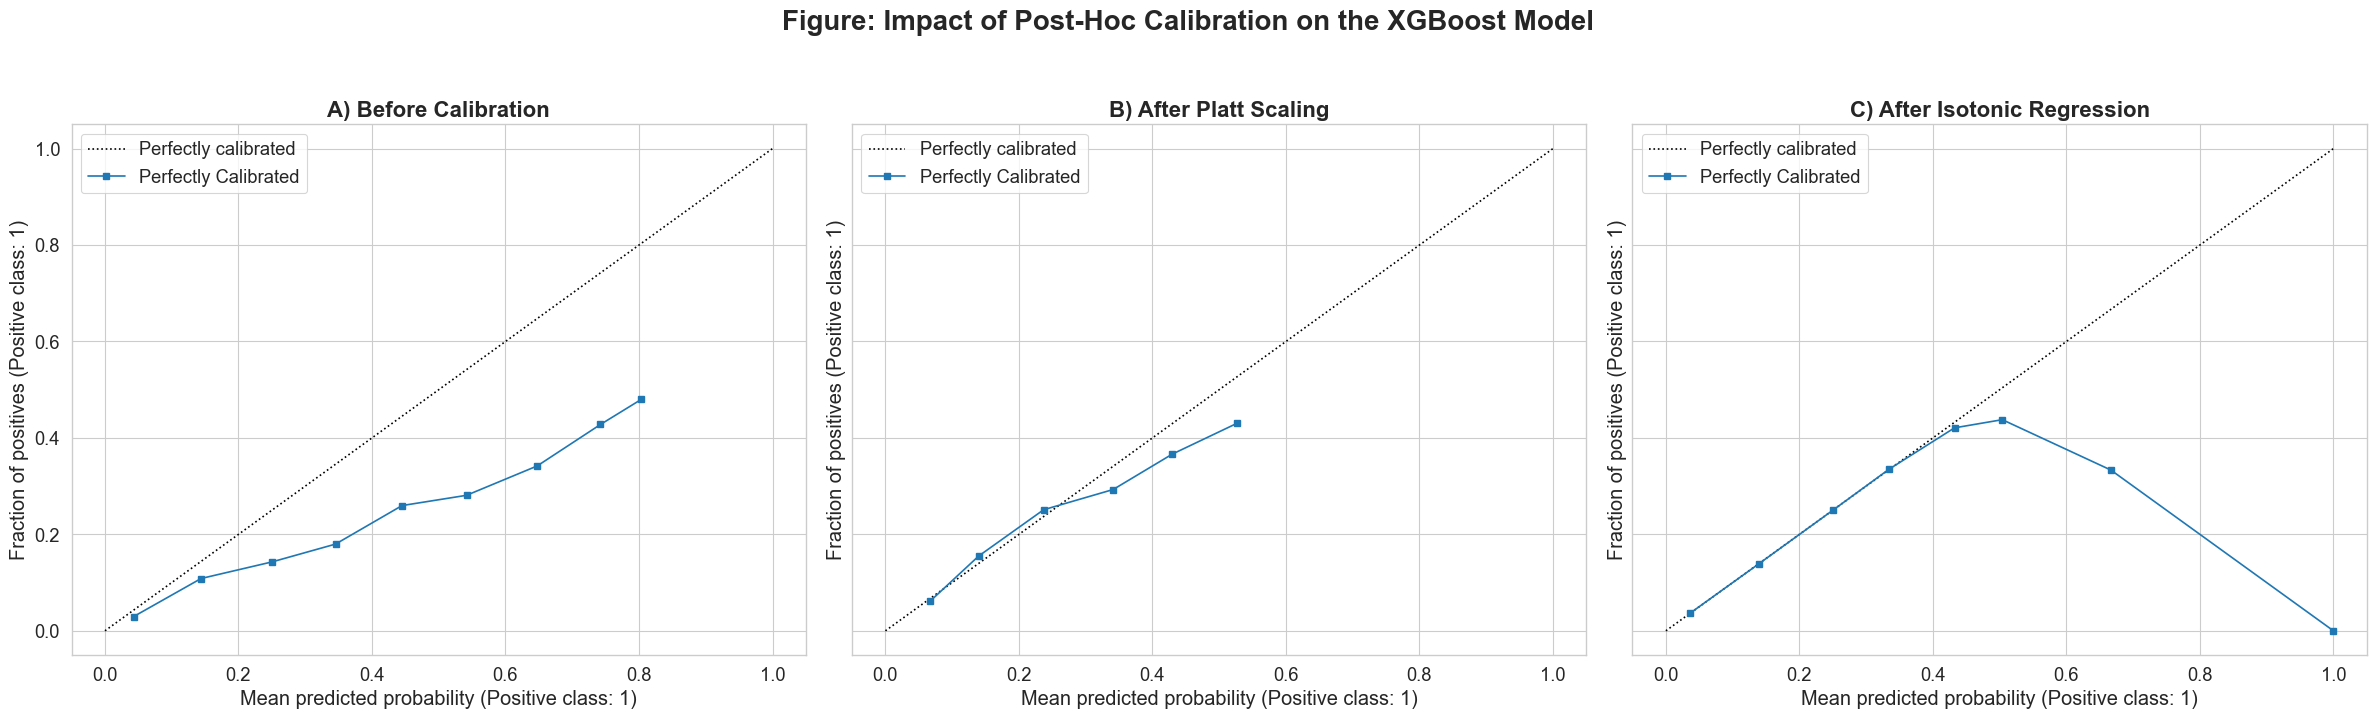


Supplementary table and figure have been saved to the '../reports' folder.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
import os

print("Starting Supplementary Analysis 1: Calibration Correction...")

# --- 1. Setup & Load Data ---
sns.set_style("whitegrid")
sns.set_context("paper", font_scale=1.5)
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_external = pd.read_csv(external_preds_path)
print("Successfully loaded external prediction file.")

y_true = df_external['y_true']
y_pred_proba = df_external['y_pred_proba']

# --- 2. Split Data into Calibration and Test Sets ---
y_pred_calib, y_pred_test, y_true_calib, y_true_test = train_test_split(
    y_pred_proba, y_true, test_size=0.5, stratify=y_true, random_state=42
)
print(f"Split BRFSS data into {len(y_true_calib)} for calibration and {len(y_true_test)} for testing.")

# --- 3. Train the Calibrators (FINAL CORRECTED VERSION) ---
# --- THIS IS THE CORRECTED PART ---
# Create a dummy estimator
dummy_estimator = LogisticRegression()
# Fit the dummy estimator on a tiny dataset with TWO classes (0 and 1) to satisfy the check
dummy_estimator.fit([[0], [1]], [0, 1])

# Now, provide this pre-fitted dummy estimator to the calibrators
platt_calibrator = CalibratedClassifierCV(dummy_estimator, method='sigmoid', cv='prefit')
platt_calibrator.fit(y_pred_calib.values.reshape(-1, 1), y_true_calib)

isotonic_calibrator = CalibratedClassifierCV(dummy_estimator, method='isotonic', cv='prefit')
isotonic_calibrator.fit(y_pred_calib.values.reshape(-1, 1), y_true_calib)
# --- END OF CORRECTION ---
print("Successfully trained Platt and Isotonic calibrators.")

# --- 4. Apply Calibrators to the Test Set ---
y_pred_platt = platt_calibrator.predict_proba(y_pred_test.values.reshape(-1, 1))[:, 1]
y_pred_isotonic = isotonic_calibrator.predict_proba(y_pred_test.values.reshape(-1, 1))[:, 1]

# --- 5. Generate the Summary Table ---
brier_uncalibrated = brier_score_loss(y_true_test, y_pred_test)
brier_platt = brier_score_loss(y_true_test, y_pred_platt)
brier_isotonic = brier_score_loss(y_true_test, y_pred_isotonic)

calib_table_data = [
    {'Method': 'Uncalibrated (Original)', 'Brier Score': brier_uncalibrated},
    {'Method': 'Platt Scaling', 'Brier Score': brier_platt},
    {'Method': 'Isotonic Regression', 'Brier Score': brier_isotonic}
]
supp_table1 = pd.DataFrame(calib_table_data).set_index('Method')

print("\n\n--- Supplementary Table: Calibration Correction Performance ---")
display(supp_table1)

output_dir = '../reports'
os.makedirs(output_dir, exist_ok=True)
supp_table1.to_csv(os.path.join(output_dir, 'Supplementary_Table_1_Calibration_Correction.csv'))

# --- 6. Generate the "Before vs. After" Figure ---
fig, axes = plt.subplots(1, 3, figsize=(24, 7), sharey=True)

CalibrationDisplay.from_predictions(y_true_test, y_pred_test, n_bins=10, ax=axes[0], name='Uncalibrated')
axes[0].set_title('A) Before Calibration', fontsize=16, weight='bold')

CalibrationDisplay.from_predictions(y_true_test, y_pred_platt, n_bins=10, ax=axes[1], name='Platt Scaling')
axes[1].set_title('B) After Platt Scaling', fontsize=16, weight='bold')

CalibrationDisplay.from_predictions(y_true_test, y_pred_isotonic, n_bins=10, ax=axes[2], name='Isotonic Regression')
axes[2].set_title('C) After Isotonic Regression', fontsize=16, weight='bold')

for ax in axes:
    ax.get_lines()[1].set_label('Perfectly Calibrated')
    ax.legend(loc='upper left')

fig.suptitle('Figure: Impact of Post-Hoc Calibration on the XGBoost Model', fontsize=20, weight='bold', y=1.03)
plt.tight_layout()

output_path_fig = os.path.join(output_dir, 'Supplementary_Figure_1_Calibration_Correction.png')
plt.savefig(output_path_fig, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSupplementary table and figure have been saved to the '{output_dir}' folder.")

In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import xgboost as xgb

print("Starting Sensitivity Analysis 2a: Impact of Imputation Method...")

# --- 1. Load Data ---
nhanes_filepath = r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv'
brfss_filepath = r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv'
df_nhanes_orig = pd.read_csv(nhanes_filepath)
df_brfss_orig = pd.read_csv(brfss_filepath)
df_nhanes_orig.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss_orig.dropna(subset=['Diabetes_Outcome'], inplace=True)
print("Successfully loaded datasets.")

# --- 2. Define a Helper Function for the Analysis ---
def evaluate_imputation_strategy(imputation_strategy, df_nhanes, df_brfss):
    common_features = ['Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke']
    
    if imputation_strategy == 'complete_case':
        df_nhanes = df_nhanes.dropna(subset=common_features)
        df_brfss = df_brfss.dropna(subset=common_features)
        X_train_imputed = df_nhanes[common_features]
        y_train = df_nhanes['Diabetes_Outcome']
        X_test_imputed = df_brfss[common_features]
        y_test = df_brfss['Diabetes_Outcome']
    else:
        X_train, y_train = df_nhanes[common_features], df_nhanes['Diabetes_Outcome']
        X_test, y_test = df_brfss[common_features], df_brfss['Diabetes_Outcome']
        
        # Separate imputers for continuous and categorical features
        imputer_cont = SimpleImputer(strategy=imputation_strategy) # median or mean
        imputer_cat = SimpleImputer(strategy='most_frequent') # mode

        cont_features = ['Age', 'BMI']
        cat_features = [col for col in common_features if col not in cont_features]

        # Fit on training data and transform both
        X_train_cont_imputed = imputer_cont.fit_transform(X_train[cont_features])
        X_test_cont_imputed = imputer_cont.transform(X_test[cont_features])
        X_train_cat_imputed = imputer_cat.fit_transform(X_train[cat_features])
        X_test_cat_imputed = imputer_cat.transform(X_test[cat_features])

        X_train_imputed = np.concatenate([X_train_cont_imputed, X_train_cat_imputed], axis=1)
        X_test_imputed = np.concatenate([X_test_cont_imputed, X_test_cat_imputed], axis=1)

    # Train and evaluate model
    model = xgb.XGBClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train_imputed, y_train)
    y_pred_proba = model.predict_proba(X_test_imputed)[:, 1]
    auc = roc_auc_score(y_test, y_pred_proba)
    return auc

# --- 3. Run Analyses and Build Table ---
results = []
strategies = {'Median/Mode (current)': 'median', 'Mean/Mode': 'mean', 'Complete Case Analysis': 'complete_case'}

for name, strategy in strategies.items():
    print(f"Evaluating: {name}...")
    auc_score = evaluate_imputation_strategy(strategy, df_nhanes_orig.copy(), df_brfss_orig.copy())
    results.append({'Imputation Strategy': name, 'External AUC': auc_score})

supp_table2a = pd.DataFrame(results).set_index('Imputation Strategy')

print("\n\n--- Supplementary Table: Sensitivity to Missing Data Handling ---")
display(supp_table2a)
supp_table2a.to_csv('../reports/Supplementary_Table_2a_Imputation_Sensitivity.csv')

Starting Sensitivity Analysis 2a: Impact of Imputation Method...
Successfully loaded datasets.
Evaluating: Median/Mode (current)...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:27:23] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating: Mean/Mode...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:27:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating: Complete Case Analysis...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:27:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)




--- Supplementary Table: Sensitivity to Missing Data Handling ---


,External AUC
Imputation Strategy,
Median/Mode (current),0.717159
Mean/Mode,0.710703
Complete Case Analysis,0.731573


In [10]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix

print("\nStarting Sensitivity Analysis 2b: Impact of Threshold Selection...")

# --- 1. Load External Validation Predictions ---
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_preds = pd.read_csv(external_preds_path)
y_true = df_preds['y_true']
y_pred_proba = df_preds['y_pred_proba']
print("Loaded prediction file.")

# --- 2. Calculate Metrics at Different Thresholds ---
thresholds = [0.05, 0.10, 0.15, 0.184, 0.20, 0.25, 0.30]
results = []

for thresh in thresholds:
    y_pred_class = (y_pred_proba >= thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred_class).ravel()
    
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)
    f1_score = 2 * (sensitivity * ppv) / (sensitivity + ppv)
    
    note = "Optimal (Youden's J)" if thresh == 0.184 else ""
    results.append({
        'Threshold': thresh, 'Sensitivity': sensitivity, 'Specificity': specificity,
        'PPV': ppv, 'F1 Score': f1_score, 'Note': note
    })

supp_table2b = pd.DataFrame(results).set_index('Threshold')

print("\n\n--- Supplementary Table: Performance at Different Probability Thresholds ---")
display(supp_table2b)
supp_table2b.to_csv('../reports/Supplementary_Table_2b_Threshold_Sensitivity.csv')


Starting Sensitivity Analysis 2b: Impact of Threshold Selection...
Loaded prediction file.


--- Supplementary Table: Performance at Different Probability Thresholds ---


,Sensitivity,Specificity,PPV,F1 Score,Note
Threshold,,,,,
0.050,0.979446,0.203084,0.158850,0.273364,
0.100,0.936349,0.323305,0.175334,0.295361,
0.150,0.844904,0.449837,0.190920,0.311461,
0.184,0.798183,0.502318,0.197709,0.316918,Optimal (Youden's J)
0.200,0.770554,0.530374,0.201350,0.319272,
0.250,0.669113,0.626571,0.215882,0.326442,
0.300,0.566127,0.719434,0.236667,0.333793,


In [11]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import xgboost as xgb

print("\nStarting Sensitivity Analysis 2c: Impact of Feature Set...")

# --- 1. Load Data ---
# (Loading code is the same as the first analysis)
df_nhanes_orig = pd.read_csv(r'C:\diabetes_prediction_project\data\03_processed\nhanes_final.csv')
df_brfss_orig = pd.read_csv(r'C:\diabetes_prediction_project\data\03_processed\brfss_final.csv')
df_nhanes_orig.dropna(subset=['Diabetes_Outcome'], inplace=True)
df_brfss_orig.dropna(subset=['Diabetes_Outcome'], inplace=True)

# --- 2. Define a Helper Function ---
def evaluate_feature_set(features, df_nhanes, df_brfss):
    X_train, y_train = df_nhanes[features], df_nhanes['Diabetes_Outcome']
    X_test, y_test = df_brfss[features], df_brfss['Diabetes_Outcome']
    
    imputer = SimpleImputer(strategy='median')
    X_train_imputed = imputer.fit_transform(X_train)
    X_test_imputed = imputer.transform(X_test)
    
    model = xgb.XGBClassifier(learning_rate=0.05, max_depth=3, n_estimators=200, use_label_encoder=False, eval_metric='logloss', random_state=42)
    model.fit(X_train_imputed, y_train)
    y_pred_proba = model.predict_proba(X_test_imputed)[:, 1]
    return roc_auc_score(y_test, y_pred_proba)

# --- 3. Define Feature Sets and Run Analyses ---
feature_sets = {
    'Full Model (8 features)': ['Age', 'Gender', 'Race_Ethnicity', 'BMI', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'],
    'Without Race/Ethnicity': ['Age', 'Gender', 'BMI', 'Smoking_Status', 'Physical_Activity', 'History_Heart_Attack', 'History_Stroke'],
    'Age + BMI only': ['Age', 'BMI']
}
results = []

for name, features in feature_sets.items():
    print(f"Evaluating: {name}...")
    auc_score = evaluate_feature_set(features, df_nhanes_orig.copy(), df_brfss_orig.copy())
    results.append({'Feature Set': name, 'External AUC': auc_score})

supp_table2c = pd.DataFrame(results).set_index('Feature Set')

print("\n\n--- Supplementary Table: Impact of Feature Inclusion/Exclusion ---")
display(supp_table2c)
supp_table2c.to_csv('../reports/Supplementary_Table_2c_Feature_Sensitivity.csv')


Starting Sensitivity Analysis 2c: Impact of Feature Set...
Evaluating: Full Model (8 features)...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:57:20] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating: Without Race/Ethnicity...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:57:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Evaluating: Age + BMI only...


c:\diabetes_prediction_project\.venv\Lib\site-packages\xgboost\training.py:183: UserWarning: [17:57:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)




--- Supplementary Table: Impact of Feature Inclusion/Exclusion ---


,External AUC
Feature Set,
Full Model (8 features),0.717159
Without Race/Ethnicity,0.736591
Age + BMI only,0.747686


In [12]:
import pandas as pd
import numpy as np

print("Starting Supplementary Analysis 3: Cost-Benefit Analysis...")

# --- 1. Define Healthcare Economics Assumptions ---
# These are hypothetical but plausible values based on literature.
# In a real study, these would be sourced from economic papers.
# All costs are per 1,000 patients.
COST_SCREENING = 50       # Cost of a single screening test (e.g., blood test)
COST_INTERVENTION = 500   # Cost per year of an intervention (medication, coaching)
COST_UNDIAGNOSED_DIABETES = 8000 # Cost per year of complications from an undiagnosed case

QALY_GAIN_PER_CASE_PREVENTED = 0.8 # Health benefit (in Quality-Adjusted Life Years) from a timely intervention
WTP_THRESHOLD = 50000     # Willingness-To-Pay per QALY (standard in US)

# --- 2. Load External Validation Predictions ---
external_preds_path = r'C:\diabetes_prediction_project\notebooks\results\external_validation_predictions.csv'
df_preds = pd.read_csv(external_preds_path)
y_true = df_preds['y_true']
y_pred_proba = df_preds['y_pred_proba']
n_total = len(y_true)
prevalence = np.mean(y_true)
print("Loaded prediction file.")

# --- 3. Define a Helper Function for Analysis ---
def calculate_cost_effectiveness(y_true, y_pred_class, is_model_strategy=True):
    n_total = len(y_true)
    tn, fp, fn, tp = np.bincount(y_true * 2 + y_pred_class, minlength=4)
    
    # Scale numbers to per 1,000 patients
    scale = 1000 / n_total
    tp, fp, fn, tn = tp * scale, fp * scale, fn * scale, tn * scale
    
    interventions = tp + fp
    
    # Calculate total cost
    cost = 0
    if is_model_strategy:
        cost += 1000 * COST_SCREENING  # Screen everyone
    cost += interventions * COST_INTERVENTION # Cost of intervening
    cost += fn * COST_UNDIAGNOSED_DIABETES # Cost of missed cases
    
    # Calculate total health benefit
    qalys_gained = tp * QALY_GAIN_PER_CASE_PREVENTED
    
    return {
        'Interventions per 1000': interventions, 'True Positives': tp,
        'False Positives': fp, 'Missed Cases': fn,
        'Total Cost ($)': cost, 'QALYs Gained': qalys_gained
    }

# --- 4. Analyze Different Strategies ---
strategies = []

# Strategy 1: Treat None
y_pred_none = np.zeros_like(y_true)
res_none = calculate_cost_effectiveness(y_true, y_pred_none, is_model_strategy=False)
res_none['Strategy'] = 'Treat None'
strategies.append(res_none)

# Strategy 2: Treat All
y_pred_all = np.ones_like(y_true)
res_all = calculate_cost_effectiveness(y_true, y_pred_all, is_model_strategy=False)
res_all['Strategy'] = 'Treat All'
strategies.append(res_all)

# Model-based strategies at different thresholds
thresholds_to_test = [0.10, 0.184, 0.25, 0.30]
for thresh in thresholds_to_test:
    y_pred_model = (y_pred_proba >= thresh).astype(int)
    res_model = calculate_cost_effectiveness(y_true, y_pred_model)
    res_model['Strategy'] = f'Model @ {thresh*100:.1f}% Threshold'
    strategies.append(res_model)
    
df_ce = pd.DataFrame(strategies).set_index('Strategy')

# --- 5. Calculate ICER (Incremental Cost-Effectiveness Ratio) ---
# ICER = (Cost_new - Cost_baseline) / (QALYs_new - QALYs_baseline)
# Here, 'Treat None' is our baseline
baseline_cost = df_ce.loc['Treat None', 'Total Cost ($)']
baseline_qalys = df_ce.loc['Treat None', 'QALYs Gained']

df_ce['ICER ($ per QALY)'] = (df_ce['Total Cost ($)'] - baseline_cost) / (df_ce['QALYs Gained'] - baseline_qalys)

# Format for display
formatted_df = df_ce.copy()
for col in ['Total Cost ($)', 'ICER ($ per QALY)']:
    formatted_df[col] = formatted_df[col].apply(lambda x: f'${x:,.0f}' if pd.notnull(x) else 'N/A')

print("\n\n--- Supplementary Table: Cost-Effectiveness Analysis ---")
display(formatted_df)
df_ce.to_csv('../reports/Supplementary_Table_3_Cost_Effectiveness.csv')

Starting Supplementary Analysis 3: Cost-Benefit Analysis...
Loaded prediction file.


--- Supplementary Table: Cost-Effectiveness Analysis ---


C:\Users\Asus\AppData\Local\Temp\ipykernel_30416\556957761.py:29: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  tn, fp, fn, tp = np.bincount(y_true * 2 + y_pred_class, minlength=4)
C:\Users\Asus\AppData\Local\Temp\ipykernel_30416\556957761.py:29: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  tn, fp, fn, tp = np.bincount(y_true * 2 + y_pred_class, minlength=4)
C:\Users\Asus\AppData\Local\Temp\ipykernel_30416\556957761.py:29: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  tn, fp, fn, tp = np.bincount(y_true * 2 + y_pred_class, minlength=4)
C:\Users\Asus\AppData\Local\Temp\ipykernel_30416\556957761.py:29: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecate

,Interventions per 1000,True Positives,False Positives,Missed Cases,Total Cost ($),QALYs Gained,ICER ($ per QALY)
Strategy,,,,,,,
Treat None,0.000000,0.000000,0.000000,133.189180,"$1,065,513",0.000000,N/A
Treat All,1000.000000,133.189180,866.810820,0.000000,"$500,000",106.551344,"$-5,307"
Model @ 10.0% Threshold,711.278458,124.711493,586.566965,8.477688,"$473,461",99.769194,"$-5,934"
Model @ 18.4% Threshold,537.705677,106.309392,431.396285,26.879788,"$533,891",85.047514,"$-6,251"
Model @ 25.0% Threshold,412.811005,89.118612,323.692393,44.070568,"$608,970",71.294890,"$-6,404"
Model @ 30.0% Threshold,318.600012,75.402000,243.198012,57.787180,"$671,597",60.321600,"$-6,530"
